# Results

This notebook includes all the results, and some notes about them

In [1]:
import json
from matplotlib import pyplot as plt
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
import pandas as pd

In [2]:
with open("all_results/arxpr2_scores.json") as f:
#with open("all_results/study_type_scores.json") as f:
    data = json.load(f)


Score data is all the scores (ones or zeros) that the averages are calculated from. These are also used for calculating p-values.

index data is the indices (of the literal, that is shufled for each paper) of the chosen answers, and the corroct answer, used to show that early indices are chosen more often.

choice data is the actual predicted and correct answers

In [3]:
score_data = data["scores"]
index_data = data["index_logs"]
choice_data = data["choice_log"]

In [4]:
len(score_data) # how many runs do we have results from?

62

To evaluate total score (not only each field) we make an array with all scores

In [5]:
def add_total_score(score_dict):
    for key in score_dict:
        total = []
        for field in score_dict[key]:
            total.extend(score_dict[key][field])
        score_dict[key]["total"] = total
add_total_score(score_data)

In [7]:
def pval(x1, x2, verbose = True): # x2 is ref
    """calculate p-value using mcnemar test. Print, or return pvalue, or nan the score is worse."""
    if not len(x1)==len(x2):
        return

    assert len(x1)==len(x2), (len(x1),len(x2))

    a,b,c,d = 0,0,0,0
    for i in range(len(x1)):
        a += x1[i] and x2[i]
        b += x1[i] and not x2[i]
        c += not x1[i] and x2[i]
        d += not x1[i] and not x2[i]

    mcnemar_matrix = [[a, b], [c, d]]

    # all of them:
    #print(mcnemar(mcnemar_matrix, exact=True))
    #print(mcnemar(mcnemar_matrix, exact=False))
    #print(mcnemar(mcnemar_matrix, exact=False, correction=False))

    # most correct(?)
    result = mcnemar(mcnemar_matrix, exact=(b+c<25), correction=min(a,b,c,d)>25)
    if verbose:

        print(field)
        print("reference better" if c>b else "reference WORSE")
        print(c, b)
        print(result)
        print("")
    return result.pvalue if c>b else np.nan
    

## get cleaner names
Since all the runs are specified by the string of arguments, its difficult to seperate them.
So we give better names

In [8]:
# print all the runs.
#for key in score_data:
#    print(key)
#    print(len(score_data[key]["total"]))

The following are shorter, more understandable names for the runs.

Best_choice is simply taking the choice/allowable answer that matches best with the chunks (without generation).
The rest of the names are described by the combination of retrieval and generation.

First word is the choice of retrieval prompt, either (field) description, all the choices (separately) or a string of the list of all the choices (choice_list). ":x" means only every x-th choice is used, the others discarded. i.e. choices:8 uses less information than choices:3.

last word is which generation model was used (gpt (4o-mini), llama (3.1 instruct 8B), mistral (7B))

In [9]:
# for verifying the names are correct
shortnames_by_argstring = {}
shortnames = []
i = 0
for argstring in score_data:
    shortname = ""
    retriever_by_key = {
        "'description":"Vanilla RAG",
        "choices":"Pre-Meta B",
        "choice-list":"Pre-Meta A",
        "onto-description":"Pre-Meta Onto"}
    for key in retriever_by_key:
        if key in argstring:
            shortname += retriever_by_key[key]
    ice_by_key = {f"('include_choice_every', {j})":":"+str(j) for j in range(2,26)}
    for key in ice_by_key:
        if key in argstring:
            shortname += ice_by_key[key]
    shortname += " + "

    model_by_key = {
        "4om":"GPT-4o mini",
        "Llama":"Llama 8B",
        "Mistral":"Mistral 7B"}
    for key in model_by_key:
        if key in argstring:
            shortname += model_by_key[key]

    if "best_choice" in argstring:
        shortname = "Pre-Meta Retrieval"
    if "full_paper" in argstring:
        shortname = "Fullpaper + GPT-4o mini"


    shortnames.append(shortname)
    shortnames_by_argstring[argstring] = shortname
    print(shortnames_by_argstring[argstring], "\t", argstring)
    i += 1

Vanilla RAG + Mistral 7B 	 [('answer_in_quotes', True), ('chunk_info_to_compare', 'direct'), ('chunk_overlap', 100), ('chunk_size', 300), ('context_shortener', 'retrieval'), ('dataset', 'arxpr2'), ('dataset_literal_length', 25), ('dataset_shuffle', 'r'), ('embedding_model', 'all-MiniLM-L6-v2'), ('ff_model', 'TheBloke/Mistral-7B-v0.1-GPTQ'), ('field_info_to_compare', 'description'), ('include_choice_every', 1), ('keyphrase_min', 1), ('keyphrase_range_diff', 1), ('listed_output', False), ('log', True), ('maxsum_factor', 1.0), ('mmr_param', 1.0), ('n_keywords', 8), ('openai_ff_max_tokens', 1000), ('outlines_ff_max_tokens', 100), ('reduce_max_tokens', 50), ('reduce_temperature', 0.4), ('remove_fields', 'non-single'), ('retriever_type', 'simple'), ('sampler', 'beam'), ('sampler_beams', 3), ('sampler_temp', 0.4), ('sampler_top_k', 100), ('sampler_top_p', 1), ('similarity_k', 4)]
Pre-Meta Retrieval 	 [('answer_in_quotes', True), ('chunk_info_to_compare', 'direct'), ('chunk_overlap', 100), ('c

## Print p-values

We now print dataframes with the significance values

This is a lot of numbers. We will report only a small selection of these I think, but all are included here so its easy to find the interesting ones.

For example we could, for each generation model, use the description-mode as baseline and provide tables/figues showing the significance of improvements by using each of the other retrieval-prompts (either [choice, choice:3, choice:5, choice:8], or choice-list, or both)

In [10]:
# make dataframes
dfs = {}
for ref_key in score_data:
    values = []
    for key in score_data:
        values.append([])
        for field in score_data[key]:
            values[-1].append(pval(score_data[key][field], score_data[ref_key][field], False))
    df = pd.DataFrame(data=values, columns= score_data[key].keys(), index=shortnames)
    dfs[ref_key] = df

In [11]:
# define print function
def p(i):
    k = list(dfs.keys())[i]
    print(shortnames[i])
    print(k)
    return dfs[k]

Now we print. 

Explanation of the print: p(0) is the results for the best_choice model. each row is the different moodels we compare with. The first is itself (not interesting). In the second row, the resutls means that best-choice is better at experimental design and assay_by_molecule, with pvalues of 28.8% (which is not significant) and 0.0032% (which is very significant) respectively, while best-choice is worse in all other fields, including the total score.

In [12]:
#p(0)

In [13]:
#p(1)

In [14]:
#p(2)

In [15]:
#p(3)

In [16]:
#p(4)

In [17]:
#p(5)

In [18]:
#p(6)

In [19]:
#p(7)

In [20]:
#p(8)

In [21]:
#p(9)

## print score tables

Markdown and latex versions of the tables.

we should still
- fix field names by removing numbers
- figure out if there are better naming conventions for the different models
- reduce number of models, and possibly split into more tables.
  - For example, choice-list is much better than choices for gpt, so we could report only these.
  - report gpt and open-source models in their own tables?
  - maybe remove one of the ":x" versions. Should keep :8 since its the least information, maybe remove :3 or :5 to simplify?


In [22]:
scores = []
for i, key in enumerate(list(score_data.keys())):
    scores.append([])
    for field in score_data[key]:
        scores[i].append(sum(score_data[key][field])/len(score_data[key][field]))
scores

df = pd.DataFrame(data=scores, columns= score_data[key].keys(), index=shortnames).sort_values("total", ascending=False)
print(df.to_markdown())
print("")


|                             |   hardware_4 |   organism_part_5 |   experimental_designs_10 |   assay_by_molecule_14 |   study_type_18 |   total |
|:----------------------------|-------------:|------------------:|--------------------------:|-----------------------:|----------------:|--------:|
| Pre-Meta A + GPT-4o mini    |         0.49 |              0.66 |                      0.39 |                   0.87 |            0.64 |   0.61  |
| Pre-Meta B + GPT-4o mini    |         0.53 |              0.74 |                      0.36 |                   0.81 |            0.55 |   0.598 |
| Pre-Meta B:2 + GPT-4o mini  |         0.49 |              0.69 |                      0.38 |                   0.65 |            0.68 |   0.578 |
| Pre-Meta Onto + GPT-4o mini |         0.5  |              0.73 |                      0.26 |                   0.81 |            0.56 |   0.572 |
| Pre-Meta A:2 + GPT-4o mini  |         0.51 |              0.71 |                      0.31 |                  

In [23]:
with open("all_results/arxpr2_semantic_scores.json") as f:
#with open("all_results/study_type_scores.json") as f:
    semantic_scores = json.load(f)
allmini_semantic_scores = semantic_scores["all-minilm:l6-v2"]
llama_semantic_scores = semantic_scores["llama3.1:8b"]

add_total_score(allmini_semantic_scores)
add_total_score(llama_semantic_scores)

In [25]:
scores = []
for i, key in enumerate(list(score_data.keys())):
    scores.append([])
    for field in score_data[key]:
        scores[i].append(sum(score_data[key][field])/len(score_data[key][field]))
    scores[i].append(sum(allmini_semantic_scores[key]["total"])/len(allmini_semantic_scores[key]["total"]))
    scores[i].append(sum(llama_semantic_scores[key]["total"])/len(llama_semantic_scores[key]["total"]))


df = pd.DataFrame(data=scores, columns= [*score_data[key].keys(), "allmini","llama"], index=shortnames).sort_values("total", ascending=False)
print(df.to_markdown())
print("")


|                             |   hardware_4 |   organism_part_5 |   experimental_designs_10 |   assay_by_molecule_14 |   study_type_18 |   total |   allmini |    llama |
|:----------------------------|-------------:|------------------:|--------------------------:|-----------------------:|----------------:|--------:|----------:|---------:|
| Pre-Meta A + GPT-4o mini    |         0.49 |              0.66 |                      0.39 |                   0.87 |            0.64 |   0.61  |  0.773533 | 0.847643 |
| Pre-Meta B + GPT-4o mini    |         0.53 |              0.74 |                      0.36 |                   0.81 |            0.55 |   0.598 |  0.772641 | 0.859397 |
| Pre-Meta B:2 + GPT-4o mini  |         0.49 |              0.69 |                      0.38 |                   0.65 |            0.68 |   0.578 |  0.762948 | 0.855912 |
| Pre-Meta Onto + GPT-4o mini |         0.5  |              0.73 |                      0.26 |                   0.81 |            0.56 |   0.572

[]

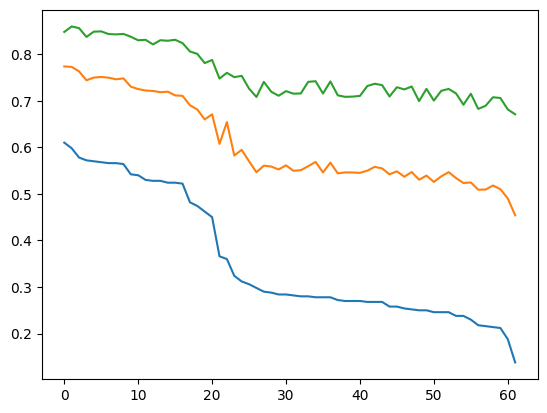

In [ ]:

for col in ["total", "allmini", "llama"]:
    plt.plot(range(len(scores)), df[col])
plt.plot()

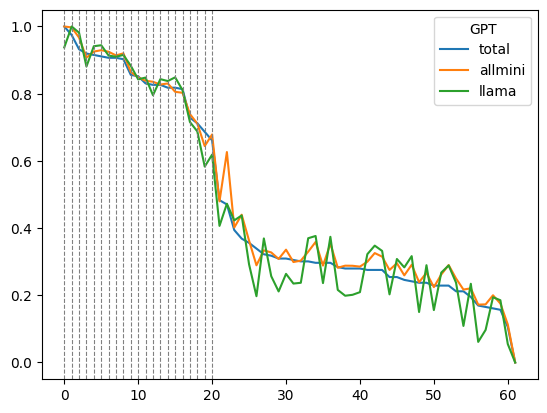

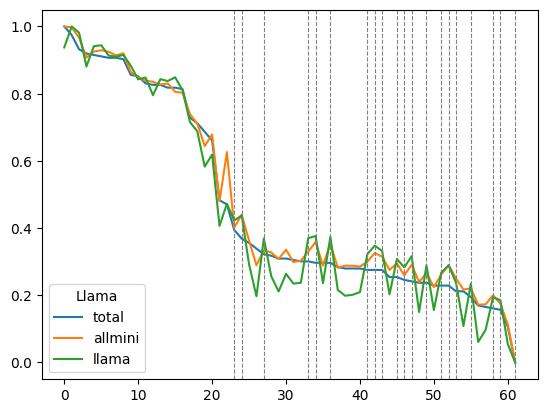

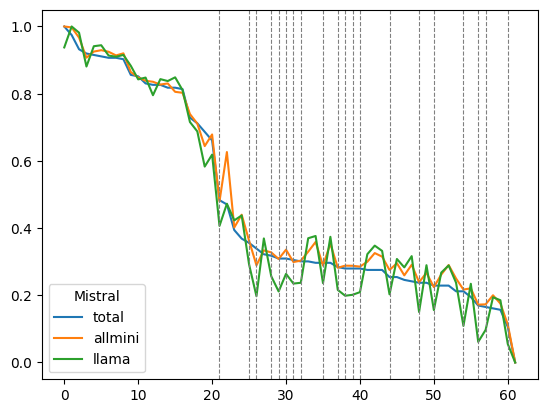

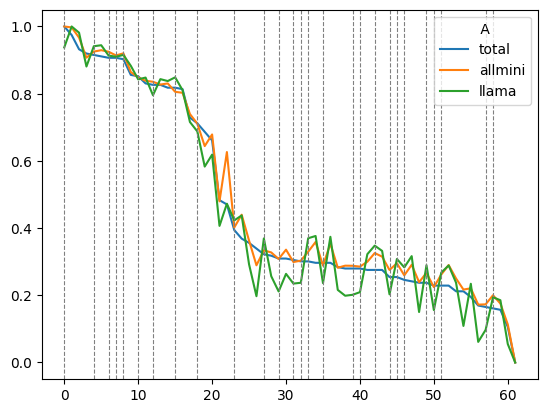

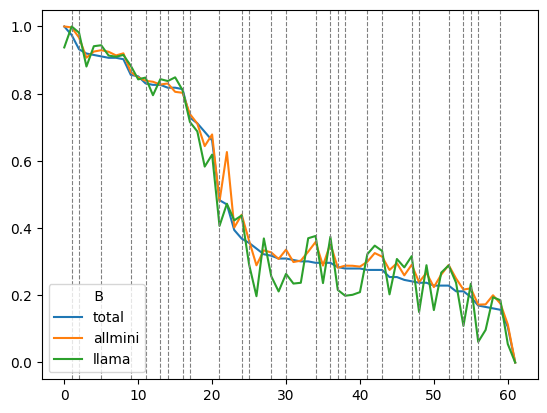

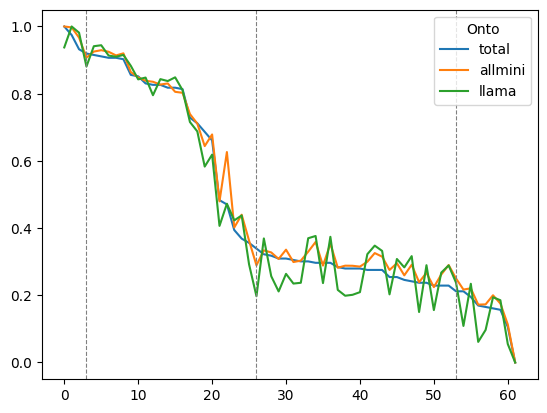

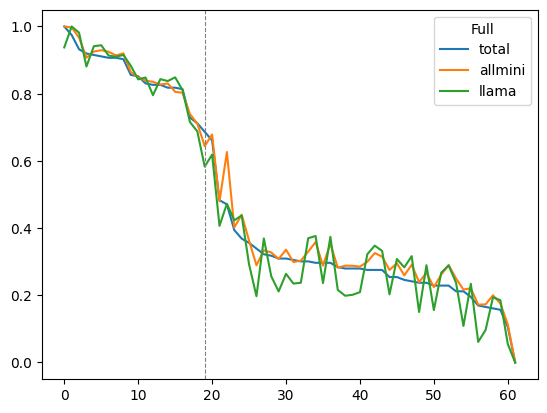

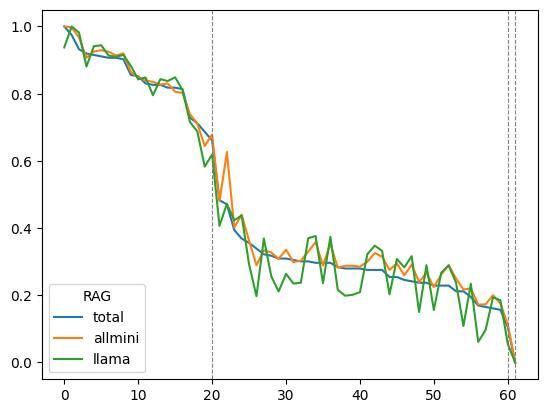

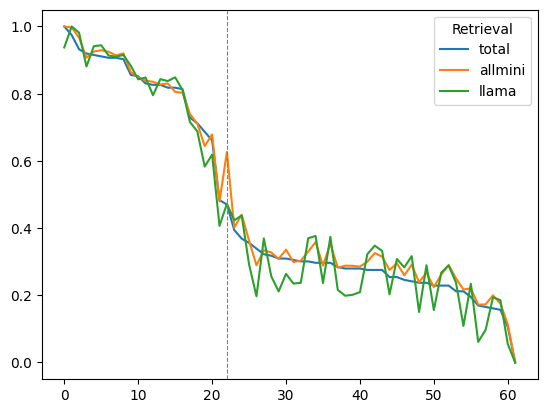

In [43]:
def plot_with_lines_showing_keywords(keyword):
    # Plot the specified columns
    for col in ["total", "allmini", "llama"]:
        plt.plot(range(len(scores)), (df[col]-min(df[col]))/(max(df[col])-min(df[col])), label=col)

    # Add gray vertical lines for rows where index contains "XX"
    for i, idx in enumerate(df.index):
        if keyword in str(idx):
            plt.axvline(x=i, color='gray', linestyle='--', linewidth=0.8)

    plt.legend(title=keyword)
    plt.show()

plot_with_lines_showing_keywords("GPT")
plot_with_lines_showing_keywords("Llama")
plot_with_lines_showing_keywords("Mistral")
plot_with_lines_showing_keywords(" A")
plot_with_lines_showing_keywords(" B")
plot_with_lines_showing_keywords("Onto")
plot_with_lines_showing_keywords("Full")
plot_with_lines_showing_keywords("RAG")
plot_with_lines_showing_keywords("Retrieval")



[]

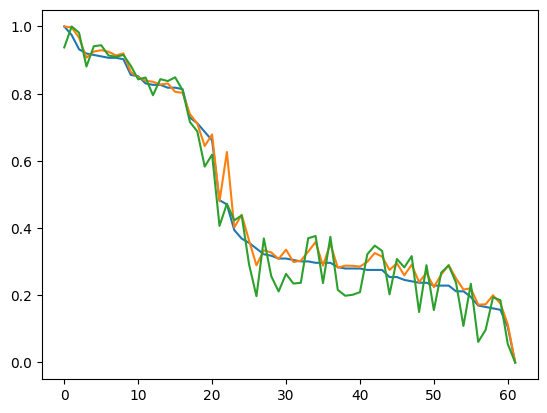

In [34]:

for col in ["total", "allmini", "llama"]:

    # original
    #plt.plot(range(len(scores)), df[col])
    # normalized
    plt.plot(range(len(scores)), (df[col]-min(df[col]))/(max(df[col])-min(df[col])))

plt.plot()

In [22]:
lt = df.to_latex()
lt = lt.replace("000 ", " ")
lt = lt.replace("_", " ")
lt = lt.replace("+", "&")
print(lt)

\begin{tabular}{lrrrrrr}
\toprule
 & hardware 4 & organism part 5 & experimental designs 10 & assay by molecule 14 & study type 18 & total \\
\midrule
Pre-Meta A & GPT-4o mini & 0.490 & 0.660 & 0.390 & 0.870 & 0.640 & 0.610 \\
Pre-Meta B & GPT-4o mini & 0.530 & 0.740 & 0.360 & 0.810 & 0.550 & 0.598 \\
Pre-Meta B:2 & GPT-4o mini & 0.490 & 0.690 & 0.380 & 0.650 & 0.680 & 0.578 \\
Pre-Meta Onto & GPT-4o mini & 0.500 & 0.730 & 0.260 & 0.810 & 0.560 & 0.572 \\
Pre-Meta A:2 & GPT-4o mini & 0.510 & 0.710 & 0.310 & 0.630 & 0.690 & 0.570 \\
Pre-Meta B:4 & GPT-4o mini & 0.490 & 0.650 & 0.350 & 0.660 & 0.690 & 0.568 \\
Pre-Meta A:4 & GPT-4o mini & 0.510 & 0.650 & 0.340 & 0.640 & 0.690 & 0.566 \\
Pre-Meta A:3 & GPT-4o mini & 0.480 & 0.680 & 0.390 & 0.630 & 0.650 & 0.566 \\
Pre-Meta A:6 & GPT-4o mini & 0.480 & 0.650 & 0.370 & 0.640 & 0.680 & 0.564 \\
Pre-Meta B:8 & GPT-4o mini & 0.470 & 0.610 & 0.310 & 0.670 & 0.650 & 0.542 \\
Pre-Meta A:8 & GPT-4o mini & 0.490 & 0.570 & 0.320 & 0.640 & 0.680 & 0.5

# sparse tag results

In [ ]:
print(1)

In [ ]:
colors = "brgcmy"
for i, model in enumerate(["GPT-4o mini", "Mistral 7B", "Llama 8B"]):
    for j, retriever in enumerate(["Pre-Meta A", "Pre-Meta B"]):
        #print(retriever)
        linename = retriever + " + " + model
        linescores = []
        ices = [1,2,3,4,5,6,8,12,24]
        ices = [1,2,3,4,6,12,24]
        #ices = [1,3,5,8]
        for ice in ices:
            #print(ice)
            ice_string = ":"+str(ice) if ice>1 else ""
            setupname = retriever+ice_string + " + " + model
            #print(setupname)
            score = df.loc[setupname]["total"]
            #print(score)
            linescores.append(score)
        
        #print(ices, linescores)

        #plt.plot(ices, linescores, color=colors[i])
        n_tags = [25//k for k in ices]
        plt.plot(n_tags, linescores, ["-o","-x"][j], label=linename, color=colors[i])


    for j, retriever in enumerate(["Pre-Meta Onto","Vanilla RAG"]):
        setupname = retriever + " + " + model
        score = df.loc[setupname]["total"]
        #plt.plot([ices[0], ices[-1]], [score, score], color=colors[i])
        plt.plot([n_tags[0], n_tags[-1]], [score, score], linestyle=["dotted","dashdot"][j], label=setupname, color=colors[i])

    if i==1:
        continue # mistral+llama on same
    plt.xscale("log")
    ax = plt.gca()
    ax.set_xticks(n_tags)
    ax.set_xticklabels(n_tags)


    plt.legend()
    plt.show()


In [ ]:
df

## index plots

In [ ]:
label_idx = {}
pred_idx = {}
label_idx_am = {}
pred_idx_am = {}

for argstring in index_data:
    label_idx[argstring] = []
    pred_idx[argstring] = []
    label_idx_am[argstring] = []
    pred_idx_am[argstring] = []
    print(argstring)
    for field in index_data[argstring]:
        if field!="assay_by_molecule_14":
            for x,y in index_data[argstring][field]:
                label_idx[argstring].append(x)
                pred_idx[argstring].append(y)
        else:
            for x,y in index_data[argstring][field]:
                label_idx_am[argstring].append(x)
                pred_idx_am[argstring].append(y)


In [ ]:
from matplotlib import pyplot as plt

### plot number of predictions of each index, for each setup

takeaways: all generation models prefer early choices, mistral really prefers the first one

First, all retrievals method with same generation method is added together.
Below that is each individual setup.

In [ ]:
for term in ["Mistral-7B", "Meta-Llama-3.1", "4om"]:
    label_counts = np.zeros(25)
    pred_counts = np.zeros(25)

    for argstring in index_data:
        if term in argstring:
            for val in label_idx[argstring]:
                label_counts[val] += 1
            for val in pred_idx[argstring]:
                pred_counts[val] += 1
        
    print(term)
    print(sum(pred_counts))
    #plt.plot(pred_counts/label_counts, "x")
    #plt.show()

    #plt.hist(x=list(range(25)), weights=pred_counts/label_counts, bins=25)
    #plt.hist(x=list(range(25)), weights=label_counts, bins=25)#, alpha=0.5)
    plt.hist(x=list(range(25)), weights=pred_counts, bins=25)#, alpha=0.8)
    plt.show()
    


In [ ]:
for term in ["Mistral-7B", "Meta-Llama-3.1", "4om"]:
    label_counts = np.zeros(3)
    pred_counts = np.zeros(3)

    for argstring in index_data:
        if term in argstring:
            for val in label_idx_am[argstring]:
                label_counts[val] += 1
            for val in pred_idx_am[argstring]:
                pred_counts[val] += 1
        
    print(term)
    print(sum(pred_counts))
    #plt.plot(pred_counts/label_counts, "x")
    #plt.show()

    #plt.hist(x=list(range(3)), weights=pred_counts/label_counts, bins=3)
    plt.hist(x=list(range(3)), weights=label_counts, bins=3)#, alpha=0.5)
    plt.hist(x=list(range(3)), weights=pred_counts, bins=3, alpha=0.8)
    plt.show()
    


In [ ]:
for argstring in index_data:
    label_counts = np.zeros(25)
    pred_counts = np.zeros(25)
    for val in label_idx[argstring]:
        label_counts[val] += 1
    for val in pred_idx[argstring]:
        pred_counts[val] += 1
        
    print(shortnames_by_argstring[argstring])
    print(sum(pred_counts))
    #plt.plot(pred_counts/label_counts, "x")
    #plt.show()

    #plt.hist(x=list(range(25)), weights=pred_counts/label_counts, bins=25)
    plt.hist(x=list(range(25)), weights=pred_counts, bins=25)
    plt.show()
    


# Choices

now we plot number of times each answer was predicted, as well as the distribution of correct answers.

This is done for each field, for each model/setup, so there is a lot of plots.

the blue is the distribution of correct answers, the orange the predicted ones. Good prediction should overlap the blue plot.

This gives a way of checking if the generation model prefers certain answers. If, for example, one of the answers is a much more common word, the model might have an artificially high probability of choosing that answer. But it seems they are quite evenly destrivbuted in most cases.


some mentionable takeaways are
- best_choice has a high preference for certain answers. I guess this means the embeddings of these answers are closer to a typical chunk of text, whatever that means?
- in organism_part, "peripheral blood" is choosen way to often, and "blood" way to rarely (for all models). A possible explanation is semantic overlap among the labels - many of the cases labeled blood could have been labeled peripheral blood, and vice versa, and the models prefer the more specific variant when appropriate.
  - for gpt, the majority of the errors in this field comes from these two answers, indicating that gpt is likely better than the numbers indicate (i.e. labels are not (much) more accurate than predictions)
- gpt does not seem to have a big preference for certain words.
- llama and mistral really prefers certain words, e.g. spleen for organism part, certain designs types and one hardware choice. This really hinders performance. Perhaps chaging decoding (e.g. temperature, or n_beams for beam search) could help.
  - for some reason, "choices-mistral" does not prefer spleen like the other versions


In [ ]:
# get all field names
import metadata_schemas
schema = metadata_schemas.get_shuffled_arxpr2(25)()

names =schema.__fields__
#names = names[0].
for field in names:
    print(list(schema.__fields__[field].annotation.__args__))


In [ ]:
schema.__fields__

In [ ]:
from collections import Counter
import metadata_schemas
schema = metadata_schemas.get_shuffled_arxpr2(25)()



for argstring in choice_data:

    print(shortnames_by_argstring[argstring])


    for field in choice_data[argstring]:
    
        labels= []
        preds = []

        #print(field)
        for label, pred in choice_data[argstring][field]:
            labels.append(label)
            preds.append(pred)
        
        commons = Counter(labels).most_common()
        commons = {t[0]:t[1] for t in commons}
        plt.bar(commons.keys(), commons.values())

        # include the rest of the labels (sorted by the default order, i.e. frequency i entire dataset)
        plt.bar(list(schema.__fields__[field].annotation.__args__), np.zeros(len(list(schema.__fields__[field].annotation.__args__))), color = "g")


        commons = Counter(preds).most_common()
        commons = {t[0]:t[1] for t in commons}
        plt.bar(commons.keys(), commons.values(), alpha=0.5)


        plt.xticks(rotation=90)
        plt.title(label=shortnames_by_argstring[argstring] + "; "+"_".join(field.split("_")[:-1]))

        
        plt.show()



# compare study type with ontology retrieval

In [ ]:
with open("all_results/study_type_scores.json") as f:
    st_data = json.load(f)

st_score_data = st_data["scores"]
st_index_data = st_data["index_logs"]
st_choice_data = st_data["choice_log"]



In [ ]:
for run_name in score_data:
    for fieldname in score_data[run_name]:
        print(fieldname)
    break

In [ ]:
print(score_data[run_name])

In [ ]:
for run_name in st_score_data:
    print(run_name)
    #for fieldname in st_score_data[run_name]:
    #    print(fieldname)
    #break

In [ ]:
for run_name in score_data:
    st_score_data[run_name] = {"study_type_18" : score_data[run_name]["study_type_18"]}


In [ ]:
len(st_score_data)

In [ ]:
st_shortnames = ["ontologydesc-mistral", "ontologydesc-gpt", "ontologydesc-llama", *shortnames]

In [ ]:
scores = []
for i, key in enumerate(list(st_score_data.keys())):
    scores.append([])
    for field in st_score_data[key]:
        scores[i].append(sum(st_score_data[key][field])/len(st_score_data[key][field]))
scores

df = pd.DataFrame(data=scores, columns= st_score_data[key].keys(), index=st_shortnames).sort_values("study_type_18", ascending=False)
print(df.to_markdown())
print("")

In [ ]:
# make dataframes
st_dfs = {}
for ref_key in st_score_data:
    values = []
    for key in st_score_data:
        values.append([])
        for field in st_score_data[key]:
            values[-1].append(pval(st_score_data[key][field], st_score_data[ref_key][field], False))
    df = pd.DataFrame(data=values, columns= st_score_data[key].keys(), index=st_shortnames)
    st_dfs[ref_key] = df


# define print function
def st_p(i):
    k = list(st_dfs.keys())[i]
    print(st_shortnames[i])
    print(k)
    return st_dfs[k]

In [ ]:
st_p(0)

In [ ]:
st_p(1)

In [ ]:
st_p(2)

# wierd distribution investigations
(work in progress)

it seems, for mistral, it just is very likely to choose either correct or the first one. Maybe it, to a large extent compared to the other ones, picks the first one where the other would pick a "random" when it is not sure? Should look into this some more

In [ ]:
for argstring in choice_data:
    if "Mistral" in argstring:# and "choice-list" in argstring:

        print(shortnames_by_argstring[argstring])


        for field in choice_data[argstring]:
        


            #print(field)
            correct_choice = []
            correct_ids = []
            pred0 = []
            for label, pred in choice_data[argstring][field]:
                correct_choice.append(int(label == pred))
            for label, pred in index_data[argstring][field]:
                correct_ids.append(int(label == pred))
                pred0.append(pred==0)
            #print(correct_ids == correct_choice)
            print(sum(correct_choice), 
                  sum(pred0), 
                  sum(np.multiply(correct_choice, pred0)) # fraction of correct 0 out of all 100
                  )
            #print("")
        
            #print(index_data[argstring][field])



TODO next:
pick 2 results to compare (e.g. best gpt and best mistral), 

In [ ]:
a = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]
len(a)

In [ ]:
for ice in range(1,26):
    b = a[ice-1::ice]
    print(ice, len(b), b)

## Plot corrrelation of semantic scores

In [47]:
for key in choice_data:
    for field in choice_data[key]:
        print(choice_data[key][field])
    break

[['illumina hiseq 2000', 'affymetrix genechip scanner 3000 7g'], ['illumina hiseq 4000', 'spectronic helios alpha uv-vis spectrophotometer'], ['illumina hiseq 4000', 'illumina miseq'], ['illumina hiseq 2500', 'illumina hiseq 2500'], ['illumina miseq', 'illumina hiseq 2000'], ['nextseq 500', 'axon- genepix4000b'], ['illumina genome analyzer ii', 'axon genepix 4000b scanning hardware'], ['illumina hiseq 2000', 'illumina miseq'], ['illumina hiseq 2000', 'illumina genome analyzer ii'], ['nextseq 500', 'nextseq 500'], ['illumina hiseq 1000', 'illumina hiseq 3000'], ['illumina hiseq 2000', 'illumina hiscansq'], ['scanning hardware', 'illumina hiseq 2500'], ['illumina genome analyzer ii', 'illumina hiscansq'], ['nextseq 500', 'ab solid 4 system'], ['illumina hiseq 4000', 'illumina genome analyzer ii'], ['illumina hiseq 2000', 'illumina hiseq 2500'], ['illumina hiseq 1000', 'illumina hiseq 3000'], ['illumina genome analyzer ii', 'illumina genome analyzer iix'], ['illumina hiseq 2500', 'illumin